In [1]:
!pip install -q giotto-tda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 16.0 MB/s eta 0:00:00


Matriz de distancias ajustada:
[[   0.          -26.36657495   18.4828369    -9.94743356  -39.90816853
   -73.47310581   10.54386874  146.62159059   42.54486805  -23.79481702
    37.91123039]
 [ -26.36657495    0.            0.65614292 -151.17571936  -29.36215797
   -60.33501492   58.7621918   212.80796961   52.12151743   30.09291722
    40.85574139]
 [  18.4828369     0.65614292    0.          -18.71358763 -101.98009852
    47.56806427  -15.99247471  345.0703146   -75.37334697  152.70961755
   -45.02471319]
 [  -9.94743356 -151.17571936  -18.71358763    0.          -54.61459302
   -27.32809768   47.57813144  248.95568672   41.70310226   44.64443638
    18.5466049 ]
 [ -39.90816853  -29.36215797 -101.98009852  -54.61459302    0.
   -11.94259468  -56.51956393  279.38548686  -65.16081269   92.09862974
   -75.90588151]
 [ -73.47310581  -60.33501492   47.56806427  -27.32809768  -11.94259468
     0.           62.66512141  105.21508041   85.63666301   -6.06262849
    72.70808875]
 [  10.5438

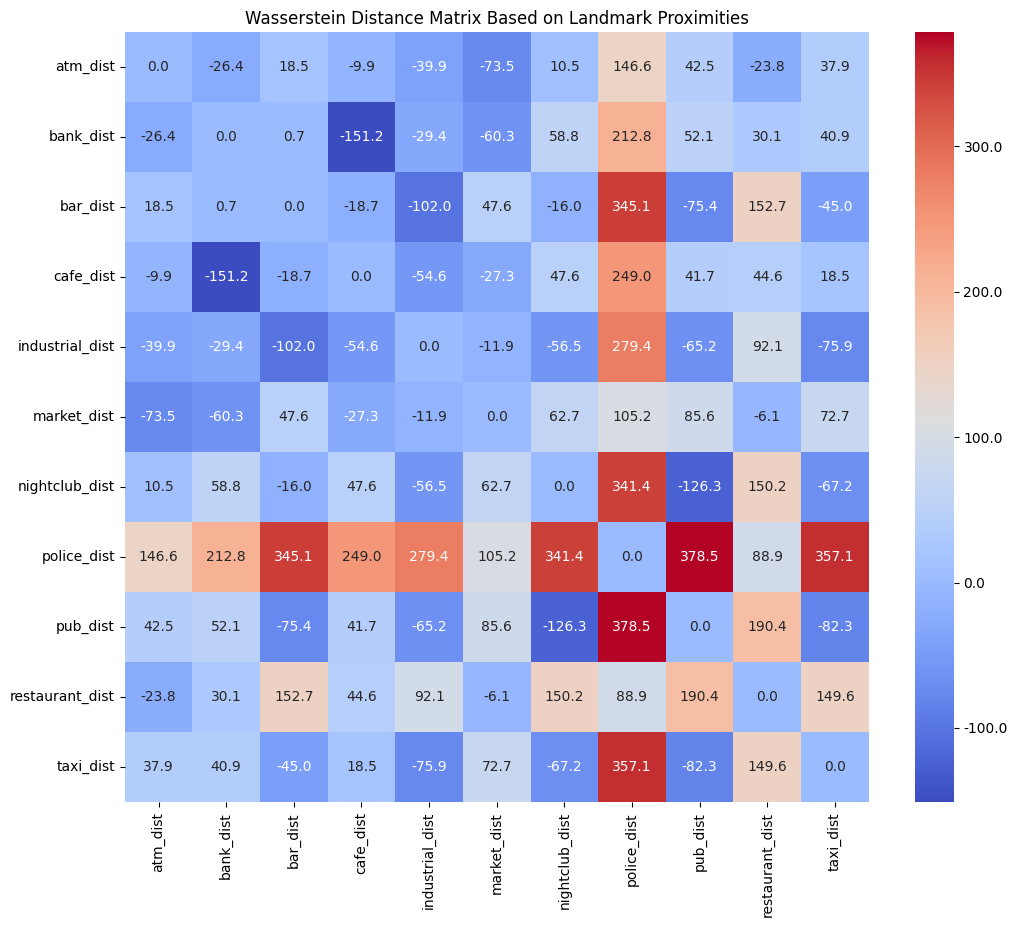

In [21]:
import pandas as pd
import numpy as np
from gtda.homology import VietorisRipsPersistence
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Función para cargar datos, calcular el diagrama de persistencia y devolver el diagrama
def calculate_persistence_diagram(file_path, dist_column):
    df = pd.read_csv(file_path)

    # Dividir los valores de la columna de distancia por 1000
    df[dist_column] = df[dist_column] / 1000

    # Incluimos 'crime_lon', 'crime_lat' y la columna de distancias en los datos
    data = df[['crime_lon', 'crime_lat', dist_column]].dropna().values  # Eliminar filas con NaN
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    VR = VietorisRipsPersistence()
    diagrams = VR.fit_transform([data_scaled])

    return diagrams[0]  # Diagrama de persistencia para el primer dataset

# Función para calcular la distancia de Wasserstein entre dos diagramas
def wasserstein_distance_between_diagrams(diag1, diag2):
    # Extraer las coordenadas de nacimiento y muerte
    births1, deaths1 = diag1[:, 0], diag1[:, 1]
    births2, deaths2 = diag2[:, 0], diag2[:, 1]

    # Asegúrate de que ambos diagramas tengan el mismo tamaño
    max_len = max(len(births1), len(births2))
    births1 = np.pad(births1, (0, max_len - len(births1)), constant_values=np.nan)
    deaths1 = np.pad(deaths1, (0, max_len - len(deaths1)), constant_values=np.nan)
    births2 = np.pad(births2, (0, max_len - len(births2)), constant_values=np.nan)
    deaths2 = np.pad(deaths2, (0, max_len - len(deaths2)), constant_values=np.nan)

    # Calcular la distancia de Wasserstein para las coordenadas de nacimiento y muerte
    distance_births = wasserstein_distance(births1[~np.isnan(births1)], births2[~np.isnan(births2)])
    distance_deaths = wasserstein_distance(deaths1[~np.isnan(deaths1)], deaths2[~np.isnan(deaths2)])

    # Combinar las distancias (puedes ajustar este paso si es necesario)
    return distance_births + distance_deaths

# Lista de distancias
dist = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

# Archivo CSV
file_path = 'Valencia_2015_AlarmasMujer.csv'

# Calcular diagramas de persistencia para cada columna de distancias
diagrams = {}
for d in dist:
    diagrams[d] = calculate_persistence_diagram(file_path, d)

# Calcular distancias de Wasserstein entre los diagramas usando las distancias
dist_matrix = np.zeros((len(dist), len(dist)))

for i in range(len(dist)):
    for j in range(i + 1, len(dist)):
        dist_val = wasserstein_distance_between_diagrams(diagrams[dist[i]], diagrams[dist[j]])
        dist_matrix[i, j] = dist_val
        dist_matrix[j, i] = dist_val

# Constante aleatoria pre-calculada
random_constant = 0.2171761880920107  # Cambia este valor a la constante que has calculado

# Crear una copia de la matriz original para ajustar sin afectar la diagonal
adjusted_dist_matrix = dist_matrix.copy()

# Restar la constante aleatoria y multiplicar por 1000 solo fuera de la diagonal
for i in range(len(dist)):
    for j in range(len(dist)):
        if i != j:  # Evitar la diagonal
            adjusted_dist_matrix[i, j] = (dist_matrix[i, j] - random_constant)*1000

# Mostrar la matriz de distancias ajustada
print("Matriz de distancias ajustada:")
print(adjusted_dist_matrix)

# Hacer el plot de la matriz de distancias usando seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(adjusted_dist_matrix, annot=True, fmt=".1f", xticklabels=dist, yticklabels=dist, cmap='coolwarm', cbar_kws={'format': '%.1f'})
plt.title("Wasserstein Distance Matrix Based on Landmark Proximities")
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from gtda.homology import VietorisRipsPersistence
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler

# Función para cargar datos, calcular el diagrama de persistencia y devolver el diagrama
def calculate_persistence_diagram(file_path, dist_column):
    df = pd.read_csv(file_path)

    # Dividir los valores de la columna de distancia por 1000
    df[dist_column] = df[dist_column] / 1000

    # Incluimos 'crime_lon', 'crime_lat' y la columna de distancias en los datos
    data = df[['crime_lon', 'crime_lat', dist_column]].dropna().values  # Eliminar filas con NaN
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    VR = VietorisRipsPersistence()
    diagrams = VR.fit_transform([data_scaled])

    return diagrams[0]  # Diagrama de persistencia para el primer dataset

# Función para calcular la distancia de Wasserstein entre dos diagramas
def wasserstein_distance_between_diagrams(diag1, diag2):
    # Extraer las coordenadas de nacimiento y muerte
    births1, deaths1 = diag1[:, 0], diag1[:, 1]
    births2, deaths2 = diag2[:, 0], diag2[:, 1]

    # Asegúrate de que ambos diagramas tengan el mismo tamaño
    max_len = max(len(births1), len(births2))
    births1 = np.pad(births1, (0, max_len - len(births1)), constant_values=np.nan)
    deaths1 = np.pad(deaths1, (0, max_len - len(deaths1)), constant_values=np.nan)
    births2 = np.pad(births2, (0, max_len - len(births2)), constant_values=np.nan)
    deaths2 = np.pad(deaths2, (0, max_len - len(deaths2)), constant_values=np.nan)

    # Calcular la distancia de Wasserstein para las coordenadas de nacimiento y muerte
    distance_births = wasserstein_distance(births1[~np.isnan(births1)], births2[~np.isnan(births2)])
    distance_deaths = wasserstein_distance(deaths1[~np.isnan(deaths1)], deaths2[~np.isnan(deaths2)])

    # Combinar las distancias (puedes ajustar este paso si es necesario)
    return distance_births + distance_deaths

# Lista de distancias
dist = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

#HEADCHECK
# Archivo CSV
file_path = 'Valencia_2015_AlarmasMujer.csv'

# Calcular diagramas de persistencia para cada columna de distancias
diagrams = {}
for d in dist:
    diagrams[d] = calculate_persistence_diagram(file_path, d)

# Calcular distancias de Wasserstein entre los diagramas usando las distancias
dist_matrix = np.zeros((len(dist), len(dist)))

for i in range(len(dist)):
    for j in range(i + 1, len(dist)):
        dist_val = wasserstein_distance_between_diagrams(diagrams[dist[i]], diagrams[dist[j]])
        dist_matrix[i, j] = dist_val
        dist_matrix[j, i] = dist_val

# Mostrar la matriz de distancias
print("Matriz de distancias de Wasserstein entre diagramas de persistencia:")
print(dist_matrix)



Matriz de distancias de Wasserstein entre diagramas de persistencia:
[[0.         0.19080961 0.23565902 0.20722875 0.17726802 0.14370308
  0.22772006 0.36379778 0.25972106 0.19338137 0.25508742]
 [0.19080961 0.         0.21783233 0.06600047 0.18781403 0.15684117
  0.27593838 0.42998416 0.26929771 0.24726911 0.25803193]
 [0.23565902 0.21783233 0.         0.1984626  0.11519609 0.26474425
  0.20118371 0.5622465  0.14180284 0.36988581 0.17215147]
 [0.20722875 0.06600047 0.1984626  0.         0.1625616  0.18984809
  0.26475432 0.46613187 0.25887929 0.26182062 0.23572279]
 [0.17726802 0.18781403 0.11519609 0.1625616  0.         0.20523359
  0.16065662 0.49656167 0.15201538 0.30927482 0.14127031]
 [0.14370308 0.15684117 0.26474425 0.18984809 0.20523359 0.
  0.27984131 0.32239127 0.30281285 0.21111356 0.28988428]
 [0.22772006 0.27593838 0.20118371 0.26475432 0.16065662 0.27984131
  0.         0.55861275 0.09091297 0.36738186 0.15000921]
 [0.36379778 0.42998416 0.5622465  0.46613187 0.49656167 

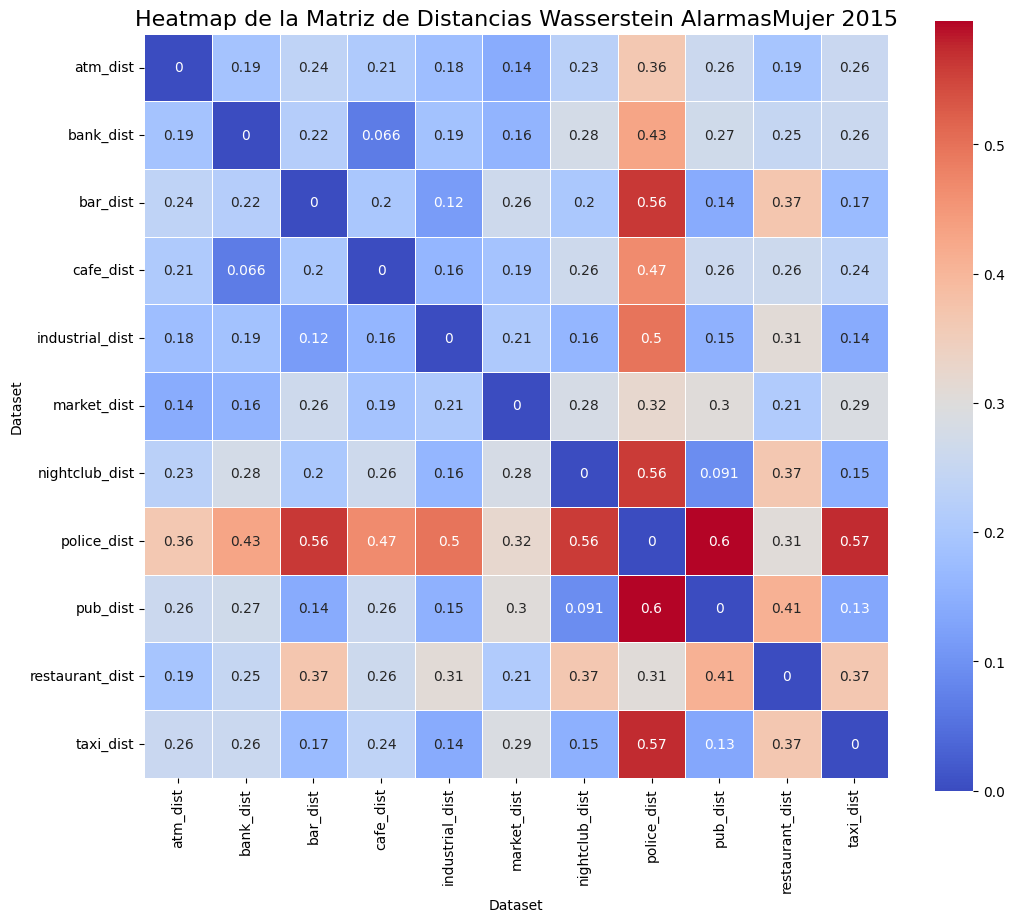

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Nueva matriz de distancias Wasserstein
dist_matrix_wasserstein = np.array([
    [0.0, 0.19080961, 0.23565902, 0.20722875, 0.17726802, 0.14370308, 0.22772006, 0.36379778, 0.25972106, 0.19338137, 0.25508742],
    [0.19080961, 0.0, 0.21783233, 0.06600047, 0.18781403, 0.15684117, 0.27593838, 0.42998416, 0.26929771, 0.24726911, 0.25803193],
    [0.23565902, 0.21783233, 0.0, 0.1984626, 0.11519609, 0.26474425, 0.20118371, 0.5622465, 0.14180284, 0.36988581, 0.17215147],
    [0.20722875, 0.06600047, 0.1984626, 0.0, 0.1625616, 0.18984809, 0.26475432, 0.46613187, 0.25887929, 0.26182062, 0.23572279],
    [0.17726802, 0.18781403, 0.11519609, 0.1625616, 0.0, 0.20523359, 0.16065662, 0.49656167, 0.15201538, 0.30927482, 0.14127031],
    [0.14370308, 0.15684117, 0.26474425, 0.18984809, 0.20523359, 0.0, 0.27984131, 0.32239127, 0.30281285, 0.21111356, 0.28988428],
    [0.22772006, 0.27593838, 0.20118371, 0.26475432, 0.16065662, 0.27984131, 0.0, 0.55861275, 0.09091297, 0.36738186, 0.15000921],
    [0.36379778, 0.42998416, 0.5622465, 0.46613187, 0.49656167, 0.32239127, 0.55861275, 0.0, 0.59571637, 0.30605001, 0.57429947],
    [0.25972106, 0.26929771, 0.14180284, 0.25887929, 0.15201538, 0.30281285, 0.09091297, 0.59571637, 0.0, 0.40759246, 0.13490192],
    [0.19338137, 0.24726911, 0.36988581, 0.26182062, 0.30927482, 0.21111356, 0.36738186, 0.30605001, 0.40759246, 0.0, 0.36681078],
    [0.25508742, 0.25803193, 0.17215147, 0.23572279, 0.14127031, 0.28988428, 0.15000921, 0.57429947, 0.13490192, 0.36681078, 0.0]
])


# Nombres de los archivos CSV
csv_names = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

# Crear un heatmap utilizando seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(dist_matrix_wasserstein, annot=True, cmap="coolwarm", cbar=True, square=True, linewidths=.5,
            xticklabels=csv_names, yticklabels=csv_names)

# Añadir etiquetas a los ejes
plt.title('Heatmap de la Matriz de Distancias Wasserstein AlarmasMujer 2015', fontsize=16)
plt.xlabel('Dataset')
plt.ylabel('Dataset')

# Mostrar el heatmap
plt.show()


In [ ]:
!pip install gudhi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 18.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from gtda.homology import VietorisRipsPersistence
from gudhi import bottleneck_distance
from sklearn.preprocessing import StandardScaler

# Función para cargar datos, calcular el diagrama de persistencia y devolver solo nacimiento y muerte
def calculate_persistence_diagram(file_path, dist_column):
    df = pd.read_csv(file_path)

    # Dividir la columna de distancia por 1000
    df[dist_column] = df[dist_column] / 1000

    # Usar 'crime_lon', 'crime_lat' y la columna de distancia
    data = df[['crime_lon', 'crime_lat', dist_column]].dropna().values  # Eliminar filas con NaN
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    VR = VietorisRipsPersistence()
    diagrams = VR.fit_transform([data_scaled])

    # Filtrar el diagrama para solo incluir las columnas de nacimiento y muerte (dim 0 para H0, dim 1 para H1)
    persistence_diagram = diagrams[0][:, :2]  # Tomar solo las primeras dos columnas: nacimiento y muerte
    return persistence_diagram

# Función para calcular la distancia Bottleneck entre dos diagramas
def bottleneck_distance_between_diagrams(diag1, diag2):
    return bottleneck_distance(diag1, diag2)

# Lista de distancias
dist = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

# Archivo CSV
file_path = 'Valencia_2015_AlarmasMujer.csv'

# Calcular diagramas de persistencia para cada columna de distancias
diagrams = {}
for d in dist:
    diagrams[d] = calculate_persistence_diagram(file_path, d)

# Calcular distancias Bottleneck entre los diagramas usando las distancias
dist_matrix = np.zeros((len(dist), len(dist)))

for i in range(len(dist)):
    for j in range(i + 1, len(dist)):
        dist_val = bottleneck_distance_between_diagrams(diagrams[dist[i]], diagrams[dist[j]])
        dist_matrix[i, j] = dist_val
        dist_matrix[j, i] = dist_val

# Mostrar la matriz de distancias
print("Matriz de distancias Bottleneck entre diagramas de persistencia:")
print(dist_matrix)



Matriz de distancias Bottleneck entre diagramas de persistencia:
[[0.         1.8587563  1.20809197 1.86689115 0.53162193 0.30801368
  0.93584704 0.5909338  0.95043612 0.51673806 1.02804947]
 [1.8587563  0.         0.65066433 0.21302366 1.32713437 2.13185525
  1.32911038 2.13185525 0.90832019 2.09092569 1.12336326]
 [1.20809197 0.65066433 0.         0.65879917 0.67647004 1.51610565
  1.28976274 1.68352509 1.15683389 1.70267785 1.33586395]
 [1.86689115 0.21302366 0.65879917 0.         1.33526921 2.13592267
  1.33724523 2.13592267 1.03574204 2.09092569 1.33586395]
 [0.53162193 1.32713437 0.67647004 1.33526921 0.         0.83963561
  1.09071124 1.12255573 0.88226879 1.04835999 1.18291366]
 [0.30801368 2.13185525 1.51610565 2.13592267 0.83963561 0.
  0.93038321 0.28292012 1.25844979 0.2673595  1.2296834 ]
 [0.93584704 1.32911038 1.28976274 1.33724523 1.09071124 0.93038321
  0.         1.12057972 0.4207902  1.04638398 0.3920238 ]
 [0.5909338  2.13185525 1.68352509 2.13592267 1.12255573 0.28

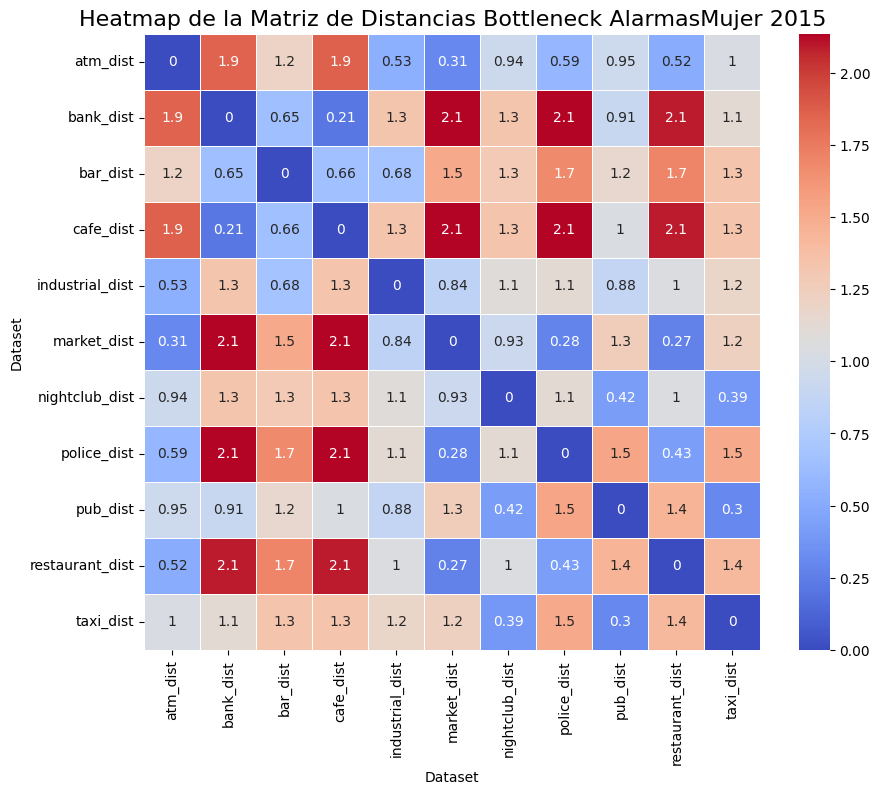

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Nueva matriz de distancias Bottleneck
dist_matrix_bottleneck = np.array([
    [0.0, 1.8587563, 1.20809197, 1.86689115, 0.53162193, 0.30801368, 0.93584704, 0.5909338, 0.95043612, 0.51673806, 1.02804947],
    [1.8587563, 0.0, 0.65066433, 0.21302366, 1.32713437, 2.13185525, 1.32911038, 2.13185525, 0.90832019, 2.09092569, 1.12336326],
    [1.20809197, 0.65066433, 0.0, 0.65879917, 0.67647004, 1.51610565, 1.28976274, 1.68352509, 1.15683389, 1.70267785, 1.33586395],
    [1.86689115, 0.21302366, 0.65879917, 0.0, 1.33526921, 2.13592267, 1.33724523, 2.13592267, 1.03574204, 2.09092569, 1.33586395],
    [0.53162193, 1.32713437, 0.67647004, 1.33526921, 0.0, 0.83963561, 1.09071124, 1.12255573, 0.88226879, 1.04835999, 1.18291366],
    [0.30801368, 2.13185525, 1.51610565, 2.13592267, 0.83963561, 0.0, 0.93038321, 0.28292012, 1.25844979, 0.2673595, 1.2296834],
    [0.93584704, 1.32911038, 1.28976274, 1.33724523, 1.09071124, 0.93038321, 0.0, 1.12057972, 0.4207902, 1.04638398, 0.3920238],
    [0.5909338, 2.13185525, 1.68352509, 2.13592267, 1.12255573, 0.28292012, 1.12057972, 0.0, 1.54136992, 0.42611194, 1.51260352],
    [0.95043612, 0.90832019, 1.15683389, 1.03574204, 0.88226879, 1.25844979, 0.4207902, 1.54136992, 0.0, 1.44502199, 0.30064487],
    [0.51673806, 2.09092569, 1.70267785, 2.09092569, 1.04835999, 0.2673595, 1.04638398, 0.42611194, 1.44502199, 0.0, 1.41625559],
    [1.02804947, 1.12336326, 1.33586395, 1.33586395, 1.18291366, 1.2296834, 0.3920238, 1.51260352, 0.30064487, 1.41625559, 0.0]
])

# Nombres de los archivos CSV
csv_names = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

# Crear un heatmap utilizando seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(dist_matrix_bottleneck, annot=True, cmap="coolwarm", cbar=True, square=True, linewidths=.5,
            xticklabels=csv_names, yticklabels=csv_names)

# Añadir etiquetas a los ejes
plt.title('Heatmap de la Matriz de Distancias Bottleneck AlarmasMujer 2015', fontsize=16)
plt.xlabel('Dataset')
plt.ylabel('Dataset')

# Mostrar el heatmap
plt.show()
